In [1]:
# This notebook analyzes crash outcomes by owning jurisdiction.
# Creates an FSI (fatal or serious injury) crash variable. The file then summarizes total crashes,
# fatalities, serious injuries, and FSI rates across jurisdiction groups and visualizes these patterns
# with bar charts and heatmaps.

# Content:
# 1. KW tests to compare outcomes across jurisdictions as normality preassumption is not satisfied
# 2. Dunn post hoc test with Holm adjustment for pairwise comparisons
# 3. Chi square test of independence to test whether FSI crash status is associated with jurisdiction
# 4. Pairwise two proportion z tests with Bfnni correction to compare FSI proportions between jurisdictions
# 5. Fisher exact test is used when sample sizes are small
# 6. It provides a more reliable p-value than asymptotic methods in sparse tables.
# 7. Shapiro Wilk tests and QQ plots to assess residual normality from OLS models
# 8. MW U test for a focused Thruway vs. non-Thruway comparison (not used).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import itertools

In [3]:
AR = pd.read_csv("AllRoads.csv")

In [4]:
AR["Owning_Jur"].value_counts()

Owning_Jur
03-Town                            4947
04-City or village                 2111
01-NYSDOT                           392
02-County                           277
90-Public - Unclaimed               161
26-Private or Restricted Access      66
12-Local Parks                       57
21-Other State agencies              49
                                     44
40-Other Public Instrumentality      40
11-State Parks                       36
31-NYS Thruway                        9
25-Other local agencies               5
74-Army                               3
Name: count, dtype: int64

In [5]:
df = pd.read_csv("2012-24_Crash_Events_std_street_names_dataset.csv")

C:\Users\Eric Zhang\AppData\Local\Temp\ipykernel_74284\3429025074.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("2012-24_Crash_Events_std_street_names_dataset.csv")


In [6]:
df.columns

Index(['CaseNumber', 'CaseYear', 'CrashDate', 'CrashTime',
       'CrashTimeFormatted', 'CrashTypeCde', 'CrashType', 'CollisionType',
       'CrashSeverity', 'LightCondition', 'WeatherCondition',
       'RoadwayAccessControlCde', 'RoadwayCharacteristic',
       'RoadSurfaceCondition', 'TrafficControl', 'TrafficWay',
       'MaxInjurySeverity', 'NumberOfFatalities', 'NumberOfInjuries',
       'NumberOfSeriousInjuries', 'NumberOfOtherInjuries', 'NumberOfVehicles',
       'PoliceDept', 'ReportingAgency', 'Precinct',
       'CommercialVehicleCrashInd', 'PPDRCode', 'NonReportable',
       'ReviewedIndicator', 'DMVInsertDate', 'CountyFIPS', 'CountyName',
       'MuniFIPS', 'CityTownName', 'OnStreet', 'ClosestCrossStreet',
       'MasterIntersectionId', 'IntersectionIndicator', 'ReferenceMarker',
       'DistanceFromIntersection', 'DirectionFromIntersection', 'UTMEasting',
       'UTMNorthing', 'NonPublicWayCode', 'ACCESS_CONTROL', 'DIVIDED',
       'FUNCTIONAL_CLASS', 'MAINT_JURISDICTION_TYP

In [7]:
df["OWNING_JURISDICTION_TYPE_ID"].value_counts()

OWNING_JURISDICTION_TYPE_ID
1.0     97645
4.0     94528
2.0     45345
3.0     16392
11.0     2308
5.0       760
9.0       301
51.0      287
7.0       115
53.0       95
6.0        49
8.0        44
Name: count, dtype: int64

In [8]:
df["MAINT_JURISDICTION_TYPE_ID"].value_counts()

MAINT_JURISDICTION_TYPE_ID
1.0     98394
4.0     94528
2.0     45339
3.0     16342
11.0     2308
9.0       301
51.0      287
7.0       115
53.0       95
58.0       56
6.0        45
8.0        44
5.0        11
54.0        4
Name: count, dtype: int64

In [9]:
# FSI
df['fatal_crash'] = (df['NumberOfFatalities'].fillna(0) > 0).astype(int)
df['serious_injury_crash'] = (df['NumberOfSeriousInjuries'].fillna(0) > 0).astype(int)
df['fsi_crash'] = ((df['fatal_crash'] == 1) | (df['serious_injury_crash'] == 1)).astype(int)

In [10]:
mapj = {
    1: "State",
    2: "County",
    3: "Town",
    4: "City/Village",
    5: "Thruway",
    6: "Interstate",
    7: "Other",
    11: "State Parks",
    999: "Unknown"
}

In [11]:
df["OWNING_JURISDICTION"] = (
    df["OWNING_JURISDICTION_TYPE_ID"]
    .map(mapj)
    .fillna("Unknown")
)

In [12]:
df["MAINT_JURISDICTION"] = (
    df["MAINT_JURISDICTION_TYPE_ID"]
    .map(mapj)
    .fillna("Unknown")
)

In [13]:
analysis = df.groupby("OWNING_JURISDICTION").agg(
        TotalCrashes = ("OWNING_JURISDICTION", "count"),
        TotalFatalities = ("NumberOfFatalities", "sum"),
        TotalSeriousInjuries = ("NumberOfSeriousInjuries", "sum"),
        TotalInjuries = ("NumberOfInjuries", "sum"),
        TotalFSI = ("fsi_crash", "sum")
      ).reset_index()

In [14]:
analysis["FatalityRate"] = analysis["TotalFatalities"] / analysis["TotalCrashes"]
analysis["SeriousInjuriesRate"] = analysis["TotalSeriousInjuries"] / analysis["TotalCrashes"]
analysis["FSIRate"] = analysis["TotalFSI"] / analysis["TotalCrashes"]

In [15]:
analysis

,OWNING_JURISDICTION,TotalCrashes,TotalFatalities,TotalSeriousInjuries,TotalInjuries,TotalFSI,FatalityRate,SeriousInjuriesRate,FSIRate
0,City/Village,94528,158,2161,22239,2058,0.001671,0.022861,0.021771
1,County,45345,104,945,11442,943,0.002294,0.020840,0.020796
2,Interstate,49,0,0,12,0,0.000000,0.000000,0.000000
3,Other,115,0,1,10,1,0.000000,0.008696,0.008696
4,State,97645,224,2221,24055,2131,0.002294,0.022746,0.021824
5,State Parks,2308,10,38,292,39,0.004333,0.016464,0.016898
6,Thruway,760,2,15,100,14,0.002632,0.019737,0.018421
7,Town,16392,22,278,2616,273,0.001342,0.016959,0.016654
8,Unknown,34492,65,560,6589,563,0.001884,0.016236,0.016323


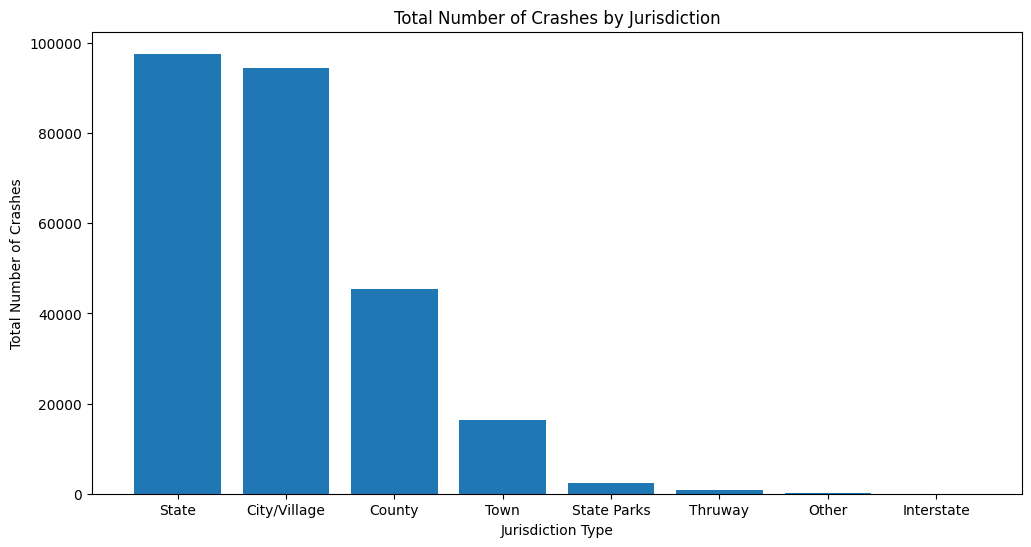

In [16]:
analysis_f = analysis[analysis["OWNING_JURISDICTION"] != "Unknown"]
analysis_s = analysis_f.sort_values("TotalCrashes", ascending = False)

plt.figure(figsize = (12, 6))

plt.bar(
    analysis_s["OWNING_JURISDICTION"],
    analysis_s["TotalCrashes"]
)

plt.xlabel("Jurisdiction Type")
plt.ylabel("Total Number of Crashes")
plt.title("Total Number of Crashes by Jurisdiction")

plt.show()

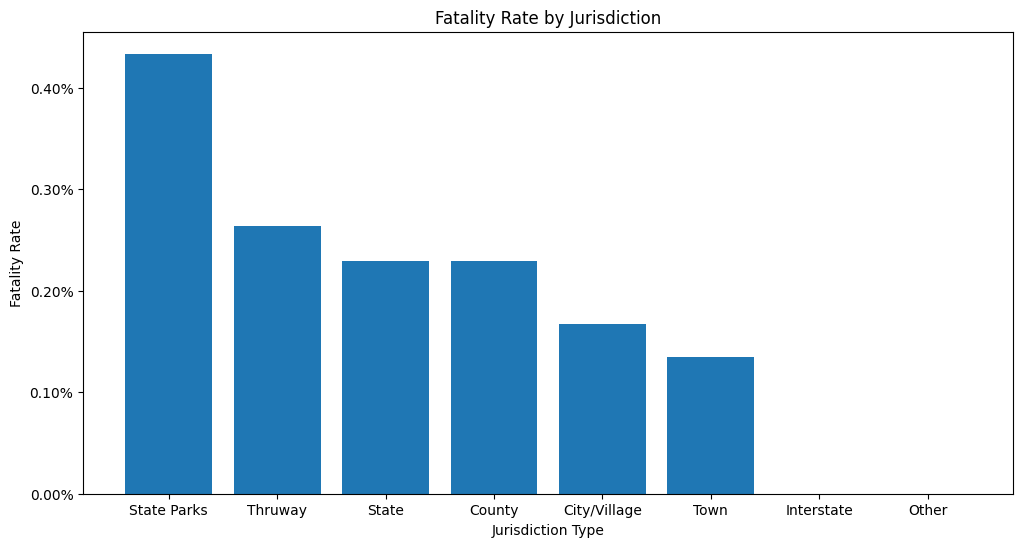

In [17]:
analysis_f = analysis[analysis["OWNING_JURISDICTION"] != "Unknown"]
analysis_s = analysis_f.sort_values("FatalityRate", ascending = False)

plt.figure(figsize = (12, 6))

plt.bar(
    analysis_s["OWNING_JURISDICTION"],
    analysis_s["FatalityRate"]
)

plt.xlabel("Jurisdiction Type")
plt.ylabel("Fatality Rate")
plt.title("Fatality Rate by Jurisdiction")

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax = 1, decimals = 2))

plt.show()

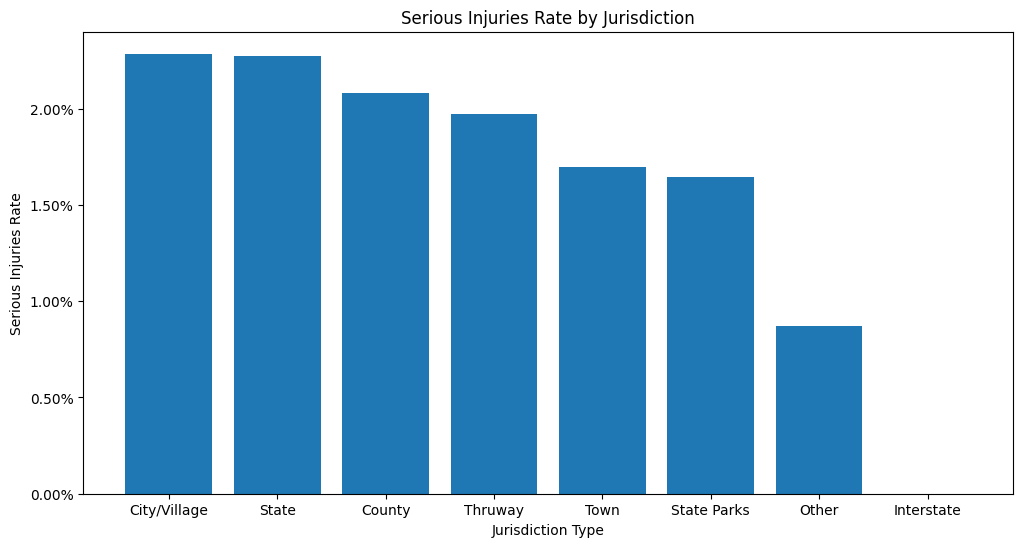

In [18]:
analysis_f = analysis[analysis["OWNING_JURISDICTION"] != "Unknown"]
analysis_s = analysis_f.sort_values("SeriousInjuriesRate", ascending = False)

plt.figure(figsize = (12, 6))

plt.bar(
    analysis_s["OWNING_JURISDICTION"],
    analysis_s["SeriousInjuriesRate"]
)

plt.xlabel("Jurisdiction Type")
plt.ylabel("Serious Injuries Rate")
plt.title("Serious Injuries Rate by Jurisdiction")
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax = 1, decimals = 2))
plt.show()

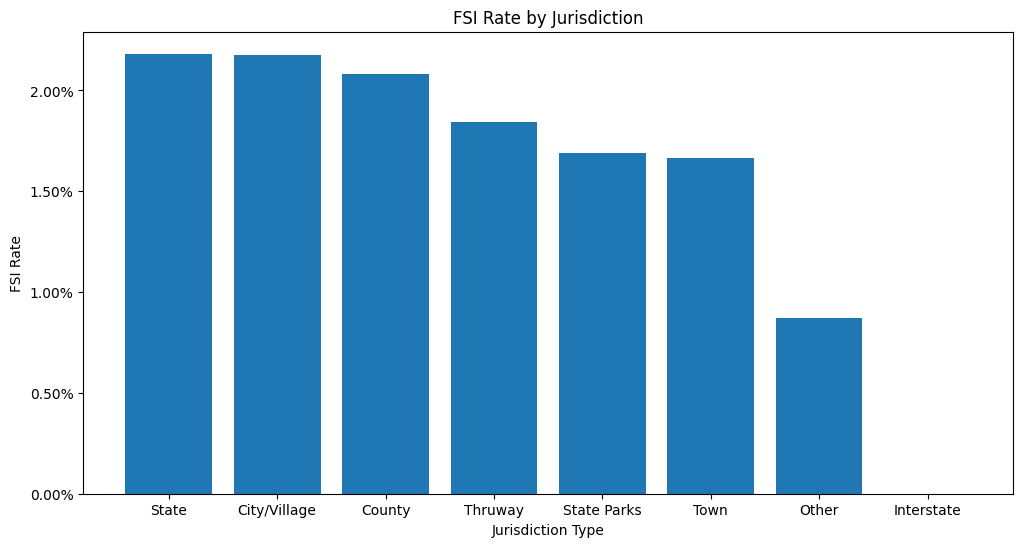

In [19]:
analysis_f = analysis[analysis["OWNING_JURISDICTION"] != "Unknown"]
analysis_s = analysis_f.sort_values("FSIRate", ascending = False)

plt.figure(figsize = (12, 6))

plt.bar(
    analysis_s["OWNING_JURISDICTION"],
    analysis_s["FSIRate"]
)

plt.xlabel("Jurisdiction Type")
plt.ylabel("FSI Rate")
plt.title("FSI Rate by Jurisdiction")
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax = 1, decimals = 2))
plt.show()

In [20]:
# KW tests to compare outcomes across jurisdictions as normality preassumption is not satisfied
# mapping original crash count to ordinal data
# [- 0.1, 0.5] → 0
# [0.5, 1.5] → 1
# [1.5, inf] → 2+

import numpy as np
import pandas as pd
from scipy.stats import kruskal
import scikit_posthocs as sp

df2 = df[
    (df["OWNING_JURISDICTION"] != "Unknown") &
    (df["OWNING_JURISDICTION"] != "Other") &
     (df["OWNING_JURISDICTION"] != "Interstate")
].copy()

df2["OWNING_JURISDICTION"] = df2["OWNING_JURISDICTION"].replace({
    "State": "NYDOT"
})

bins = [-0.1, 0.5, 1.5, np.inf]
labels = ["0", "1", "2+"]

df2["SeriousInjury_ordinal"] = pd.cut(
    df2["NumberOfSeriousInjuries"],
    bins = bins,
    labels = labels,
    ordered=True
)


df2["SeriousInjury_ordinal_code"] = pd.cut(
    df2["NumberOfSeriousInjuries"],
    bins = bins,
    labels = [0, 1, 2],
    ordered = True
).astype(int)


def kruskaltest(data, group_col, value_col):
    groups = []

    for group_name, group in data.groupby(group_col):
        result = group[value_col].dropna().values
        groups.append(result)

    stat, p = kruskal(*groups)

    print(f"KruskalWallis test for {value_col}")
    print(f"H-statistic: {stat:.6f}")
    print(f"p-value: {p:.6g}")
    print("-" * 40)

In [21]:

kruskaltest(df2, "OWNING_JURISDICTION", "NumberOfFatalities")
kruskaltest(df2, "OWNING_JURISDICTION", "NumberOfSeriousInjuries")
kruskaltest(df2, "OWNING_JURISDICTION","SeriousInjury_ordinal_code")

KruskalWallis test for NumberOfFatalities
H-statistic: 16.009702
p-value: 0.00681643
----------------------------------------
KruskalWallis test for NumberOfSeriousInjuries
H-statistic: 24.045057
p-value: 0.000212827
----------------------------------------
KruskalWallis test for SeriousInjury_ordinal_code
H-statistic: 24.042738
p-value: 0.000213045
----------------------------------------


In [22]:
# Dunn post hoc test with Holm adjustment for pairwise comparisons
import scikit_posthocs as sp

clean = df2[["OWNING_JURISDICTION", "SeriousInjury_ordinal_code"]].dropna()

duunr = sp.posthoc_dunn(
    clean,
    val_col="SeriousInjury_ordinal_code",
    group_col="OWNING_JURISDICTION",
    p_adjust="holm"
)

print(duunr)

              City/Village    County     NYDOT  State Parks  Thruway      Town
City/Village      1.000000  0.661598  1.000000     0.444217      1.0  0.000275
County            0.661598  1.000000  1.000000     1.000000      1.0  0.061298
NYDOT             1.000000  1.000000  1.000000     0.572774      1.0  0.001161
State Parks       0.444217  1.000000  0.572774     1.000000      1.0  1.000000
Thruway           1.000000  1.000000  1.000000     1.000000      1.0  1.000000
Town              0.000275  0.061298  0.001161     1.000000      1.0  1.000000


In [23]:
import scikit_posthocs as sp

# clean = df2[["OWNING_JURISDICTION", "NumberOfSeriousInjuries"]].dropna()
# duunr = sp.posthoc_dunn(clean, val_col= "NumberOfSeriousInjuries", group_col="OWNING_JURISDICTION", p_adjust= "holm" )

# print(duunr)
clean = df2[["OWNING_JURISDICTION", "SeriousInjury_ordinal_code"]].dropna()

duunr = sp.posthoc_dunn(
    clean,
    val_col="SeriousInjury_ordinal_code",
    group_col="OWNING_JURISDICTION",
    p_adjust="holm"
)

print(duunr)

              City/Village    County     NYDOT  State Parks  Thruway      Town
City/Village      1.000000  0.661598  1.000000     0.444217      1.0  0.000275
County            0.661598  1.000000  1.000000     1.000000      1.0  0.061298
NYDOT             1.000000  1.000000  1.000000     0.572774      1.0  0.001161
State Parks       0.444217  1.000000  0.572774     1.000000      1.0  1.000000
Thruway           1.000000  1.000000  1.000000     1.000000      1.0  1.000000
Town              0.000275  0.061298  0.001161     1.000000      1.0  1.000000


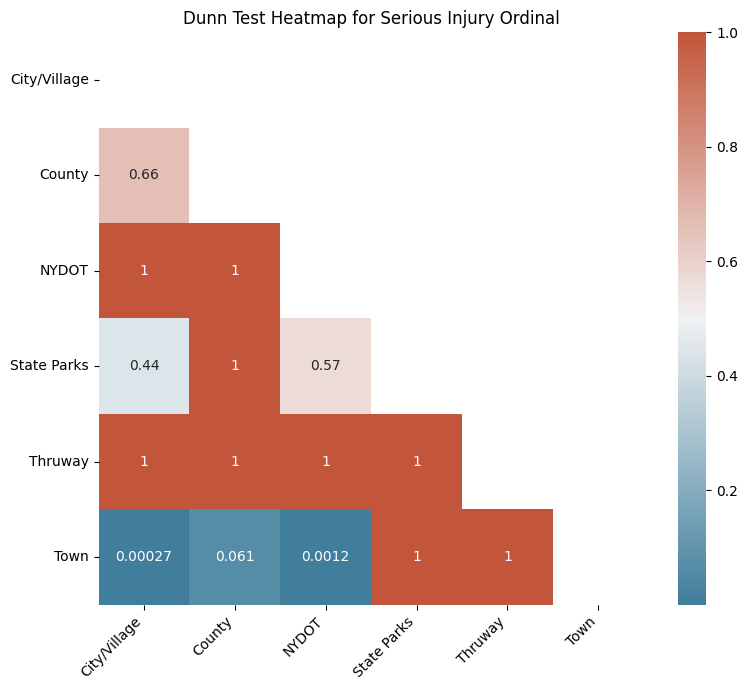

In [24]:
# plt.figure(figsize=(9, 7))
# mask = np.triu(np.ones_like(duunr, dtype = bool))
# cmap = sns.diverging_palette(230, 20, as_cmap=True)
# sns.heatmap(
#     duunr,
#     mask = mask,
#     annot=True,
#     fmt=".2g",
#     cmap= cmap,
#     linewidths=0.5,
#     square=True,
#     cbar_kws={"label": "Adjusted p-value"}
# )

# plt.title("Dunn Test Heatmap for NumberOfSeriousInjuries")
# plt.xticks(rotation=45, ha="right")
# plt.yticks(rotation=0)
# plt.tight_layout()
# plt.show()

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

order = ["City/Village", "County", "NYDOT", "State Parks", "Thruway", "Town"]

duunr = duunr.loc[order, order]
cmap = sns.diverging_palette(230, 20, as_cmap=True)
mask = np.triu(np.ones_like(duunr, dtype=bool))

plt.figure(figsize=(8, 7))
sns.heatmap(
    duunr,
    annot=True,
    fmt=".2g",
    cmap=cmap,
    mask=mask
)
plt.title("Dunn Test Heatmap for Serious Injury Ordinal")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [25]:
rate_sum = analysis_f[["OWNING_JURISDICTION", "SeriousInjuriesRate"]]
rate_sum = rate_sum[
    (rate_sum["OWNING_JURISDICTION"] != "Other") &
    (rate_sum["OWNING_JURISDICTION"] != "Interstate")
]
results = []

for (g1, r1), (g2, r2) in itertools.combinations(
    zip(rate_sum["OWNING_JURISDICTION"], rate_sum["SeriousInjuriesRate"]), 2
):
    diff = r1 - r2
    
    results.append({
        "Group1": g1,
        "Group2": g2,
        "Rate1": r1,
        "Rate2": r2,
        "Difference": diff,
        "Abs_Difference": abs(diff),
    })

pw_diff = pd.DataFrame(results)

print(pw_diff.sort_values("Abs_Difference", ascending = False))

          Group1       Group2     Rate1     Rate2  Difference  Abs_Difference
2   City/Village  State Parks  0.022861  0.016464    0.006396        0.006396
9          State  State Parks  0.022746  0.016464    0.006281        0.006281
4   City/Village         Town  0.022861  0.016959    0.005901        0.005901
11         State         Town  0.022746  0.016959    0.005786        0.005786
6         County  State Parks  0.020840  0.016464    0.004376        0.004376
8         County         Town  0.020840  0.016959    0.003881        0.003881
12   State Parks      Thruway  0.016464  0.019737   -0.003272        0.003272
3   City/Village      Thruway  0.022861  0.019737    0.003124        0.003124
10         State      Thruway  0.022746  0.019737    0.003009        0.003009
14       Thruway         Town  0.019737  0.016959    0.002777        0.002777
0   City/Village       County  0.022861  0.020840    0.002021        0.002021
5         County        State  0.020840  0.022746   -0.001905   

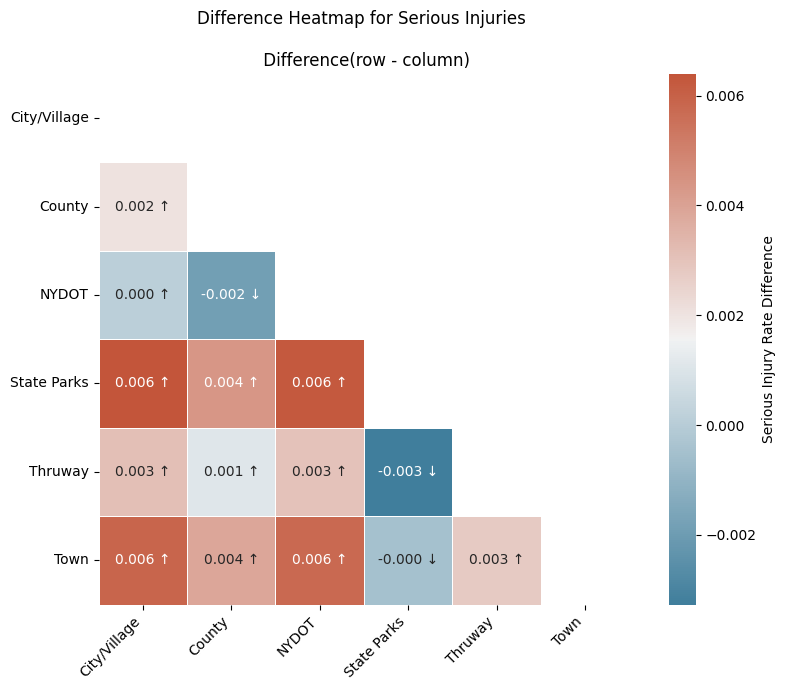

In [26]:
pw_diff["Group1"] = pw_diff["Group1"].replace({"State": "NYDOT"})
pw_diff["Group2"] = pw_diff["Group2"].replace({"State": "NYDOT"})
groups = sorted(set(pw_diff["Group1"]).union(set(pw_diff["Group2"])))

heatmap_data = pd.DataFrame(
    np.ones((len(groups), len(groups))),
    index = groups,
    columns = groups
)

for _, row in pw_diff.iterrows():
    g1 = row["Group1"]
    g2 = row["Group2"]
    Difference   = row["Difference"]
    
    heatmap_data.loc[g1, g2] = Difference  
    heatmap_data.loc[g2, g1] = Difference     

annot = heatmap_data.copy().astype(object)

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        val = heatmap_data.iloc[i, j]
        if val > 0:
            annot.iloc[i, j] = f"{val:.3f} ↑"
        elif val < 0:
            annot.iloc[i, j] = f"{val:.3f} ↓"
        else:
            annot.iloc[i, j] = "0"
mask = np.triu(np.ones_like(heatmap_data, dtype = bool))

plt.figure(figsize=(9, 7))
sns.heatmap(
    heatmap_data,
    mask = mask,
    annot = annot,
    fmt ="",
    cmap = sns.diverging_palette(230, 20, as_cmap = True),   
    linewidths = 0.5,
    square = True,
    cbar_kws={"label": "Serious Injury Rate Difference"}
)

plt.title("Difference Heatmap for Serious Injuries \n\n Difference(row - column)")
plt.xticks(rotation = 45, ha = "right")
plt.yticks(rotation = 0)
plt.tight_layout()
plt.show()

 # FSI

In [37]:
# Chi square test of independence to test whether FSI crash status is associated with jurisdiction
from scipy.stats import chi2_contingency
clean2 = df2[["OWNING_JURISDICTION", "fsi_crash"]].dropna()
ct = pd.crosstab(clean2["OWNING_JURISDICTION"], clean2["fsi_crash"])
chi2, p, dof, expected = chi2_contingency(ct)

print("Chi-square statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)


Chi-square statistic: 22.279657704701442
p-value: 0.000463226492750258
Degrees of freedom: 5


In [38]:
n = ct.to_numpy().sum()
r, c = ct.shape

cv = np.sqrt(chi2 / (n * min(r - 1, c - 1)))
print("Cramér's V:", cv)

# Cramér’s V indicates a small effect size, suggesting that the association between jurisdiction 
# type and crash type is statistically significant but not very strong in practical terms.

Cramér's V: 0.009311213497385536


In [28]:
# Pairwise two proportion z tests with Bfnni correction to compare FSI proportions between jurisdictions
import itertools
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multitest import multipletests

FSIs = clean2.groupby("OWNING_JURISDICTION")["fsi_crash"].agg(
    total = "count",
    fsi_count = "sum"
)

results = []
group = FSIs.index.tolist()

for g1, g2 in itertools.combinations(group, 2):
    pw_fsicount = [FSIs.loc[g1, "fsi_count"], FSIs.loc[g2, "fsi_count"]]
    pw_total = [FSIs.loc[g1, "total"], FSIs.loc[g2, "total"]]

    stat, p = proportions_ztest(pw_fsicount, pw_total)
    
    results.append({
        "Group1": g1,
        "Group2": g2,
        "z_stat": stat,
        "p_value": p
    })

ppt = pd.DataFrame(results)
ppt["p_adj"] = multipletests(ppt["p_value"], method = "bonferroni")[1]
print(ppt.sort_values("p_adj"))

          Group1       Group2    z_stat   p_value     p_adj
11         NYDOT         Town  4.263320  0.000020  0.000302
4   City/Village         Town  4.216390  0.000025  0.000372
8         County         Town  3.270449  0.001074  0.016107
0   City/Village       County  1.178200  0.238717  1.000000
1   City/Village        NYDOT -0.078985  0.937044  1.000000
2   City/Village  State Parks  1.589282  0.111997  1.000000
3   City/Village      Thruway  0.630734  0.528214  1.000000
5         County        NYDOT -1.247040  0.212383  1.000000
6         County  State Parks  1.285972  0.198453  1.000000
7         County      Thruway  0.455456  0.648782  1.000000
9          NYDOT  State Parks  1.605063  0.108480  1.000000
10         NYDOT      Thruway  0.639961  0.522198  1.000000
12   State Parks      Thruway -0.279549  0.779824  1.000000
13   State Parks         Town  0.085432  0.931918  1.000000
14       Thruway         Town  0.371177  0.710506  1.000000


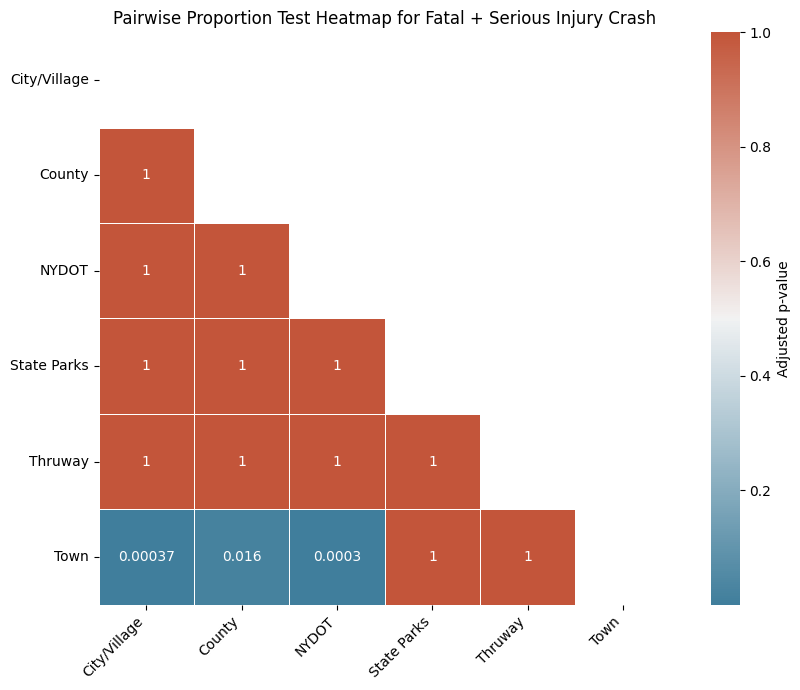

In [29]:
groups = sorted(set(ppt["Group1"]).union(set(ppt["Group2"])))

heatmap_data = pd.DataFrame(
    np.ones((len(groups), len(groups))),
    index = groups,
    columns = groups
)

for _, row in ppt.iterrows():
    g1 = row["Group1"]
    g2 = row["Group2"]
    p_adj = row["p_adj"]
    
    heatmap_data.loc[g1, g2] = p_adj
    heatmap_data.loc[g2, g1] = p_adj   

mask = np.triu(np.ones_like(heatmap_data, dtype = bool))

plt.figure(figsize=(9, 7))
sns.heatmap(
    heatmap_data,
    mask = mask,
    annot = True,
    fmt =".2g",
    cmap = sns.diverging_palette(230, 20, as_cmap = True),   
    linewidths = 0.5,
    square = True,
    cbar_kws = {"label": "Adjusted p-value"}
)

plt.title("Pairwise Proportion Test Heatmap for Fatal + Serious Injury Crash")
plt.xticks(rotation = 45, ha = "right")
plt.yticks(rotation = 0)
plt.tight_layout()
plt.show()

In [30]:
rate_sum = analysis_f[["OWNING_JURISDICTION", "FSIRate"]]
rate_sum = rate_sum[
    (rate_sum["OWNING_JURISDICTION"] != "Other") &
    (rate_sum["OWNING_JURISDICTION"] != "Interstate")
]
results = []

for (g1, r1), (g2, r2) in itertools.combinations(
    zip(rate_sum["OWNING_JURISDICTION"], rate_sum["FSIRate"]), 2
):
    diff = r1 - r2
    
    results.append({
        "Group1": g1,
        "Group2": g2,
        "Rate1": r1,
        "Rate2": r2,
        "Difference": diff,
        "Abs_Difference": abs(diff),
    })

pw_diff = pd.DataFrame(results)

print(pw_diff.sort_values("Abs_Difference", ascending = False))

          Group1       Group2     Rate1     Rate2  Difference  Abs_Difference
11         State         Town  0.021824  0.016654    0.005169        0.005169
4   City/Village         Town  0.021771  0.016654    0.005117        0.005117
9          State  State Parks  0.021824  0.016898    0.004926        0.004926
2   City/Village  State Parks  0.021771  0.016898    0.004874        0.004874
8         County         Town  0.020796  0.016654    0.004142        0.004142
6         County  State Parks  0.020796  0.016898    0.003898        0.003898
10         State      Thruway  0.021824  0.018421    0.003403        0.003403
3   City/Village      Thruway  0.021771  0.018421    0.003350        0.003350
7         County      Thruway  0.020796  0.018421    0.002375        0.002375
14       Thruway         Town  0.018421  0.016654    0.001767        0.001767
12   State Parks      Thruway  0.016898  0.018421   -0.001523        0.001523
5         County        State  0.020796  0.021824   -0.001028   

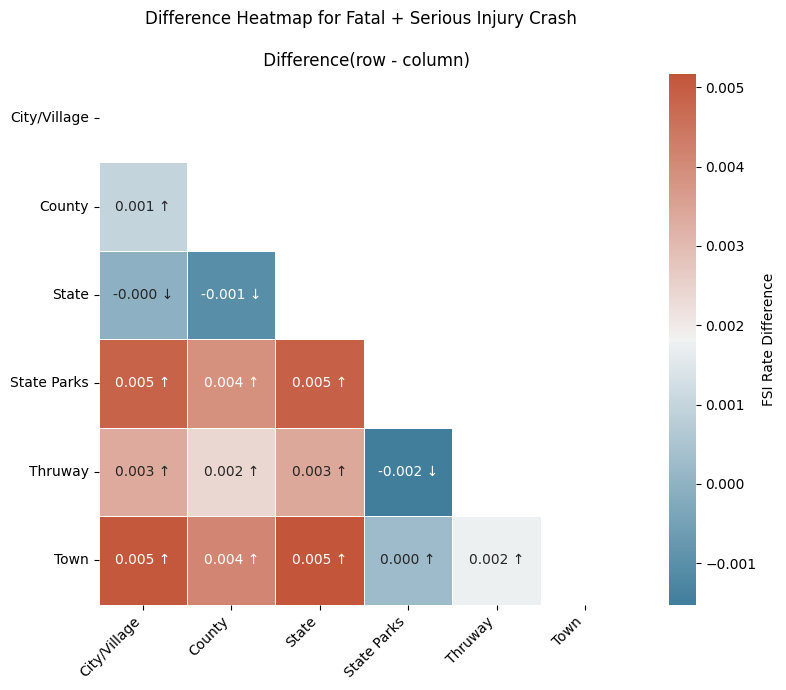

In [31]:
groups = sorted(set(pw_diff["Group1"]).union(set(pw_diff["Group2"])))

heatmap_data = pd.DataFrame(
    np.ones((len(groups), len(groups))),
    index = groups,
    columns = groups
)

for _, row in pw_diff.iterrows():
    g1 = row["Group1"]
    g2 = row["Group2"]
    diff = row["Difference"]  
    
    heatmap_data.loc[g1, g2] = diff
    heatmap_data.loc[g2, g1] = diff   


annot = heatmap_data.copy().astype(object)

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        val = heatmap_data.iloc[i, j]
        if val > 0:
            annot.iloc[i, j] = f"{val:.3f} ↑"
        elif val < 0:
            annot.iloc[i, j] = f"{val:.3f} ↓"
        else:
            annot.iloc[i, j] = "0"

mask = np.triu(np.ones_like(heatmap_data, dtype = bool))

plt.figure(figsize=(9, 7))
sns.heatmap(
    heatmap_data,
    mask = mask,
    annot = annot,
    fmt ="",
    cmap = sns.diverging_palette(230, 20, as_cmap = True),   
    linewidths = 0.5,
    square = True,
    cbar_kws = {"label": "FSI Rate Difference"}
)

plt.title("Difference Heatmap for Fatal + Serious Injury Crash \n\n Difference(row - column)")
plt.xticks(rotation = 45, ha = "right")
plt.yticks(rotation = 0)
plt.tight_layout()
plt.show()

# QQplot

In [32]:
# Shapiro Wilk tests and QQ plots to assess residual normality from OLS models
import statsmodels.formula.api as smf
from scipy.stats import shapiro

df_st = df[["OWNING_JURISDICTION_TYPE_ID", "NumberOfFatalities"]].dropna().copy()

model = smf.ols("NumberOfFatalities ~ C(OWNING_JURISDICTION_TYPE_ID)", data = df_st).fit()
residuals = model.resid

stat, p = shapiro(residuals)

print("Shapiro test result of residuals of NumberOfFatalities")
print(f"Statistic = {stat:.6f}")
print(f"p-value = {p:.6g}")

if p > 0.05:
    print("Residuals are normal")
else:
    print("Residuals are not normal")

Shapiro test result of residuals of NumberOfFatalities
Statistic = 0.021272
p-value = 1.38039e-209
Residuals are not normal


C:\Users\Eric Zhang\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 257869.
  res = hypotest_fun_out(*samples, **kwds)


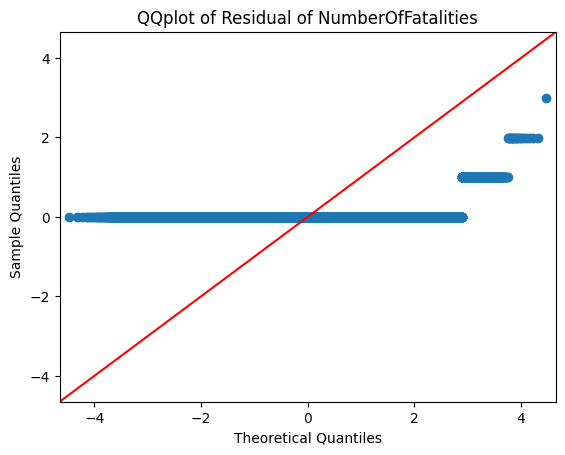

In [33]:
import statsmodels.api as sm
sm.qqplot(residuals, line='45')
plt.title("QQplot of Residual of NumberOfFatalities")
plt.show()

In [34]:
df_st = df[["OWNING_JURISDICTION_TYPE_ID", "NumberOfSeriousInjuries"]].dropna().copy()

model = smf.ols("NumberOfSeriousInjuries ~ C(OWNING_JURISDICTION_TYPE_ID)", data = df_st).fit()
residuals = model.resid

stat, p = shapiro(residuals)

print("Shapiro test result of residuals of NumberOfSeriousInjuries")
print(f"Statistic = {stat:.6f}")
print(f"p-value = {p:.6g}")

if p > 0.05:
    print("Residuals are normal")
else:
    print("Residuals are not normal")

Shapiro test result of residuals of NumberOfSeriousInjuries
Statistic = 0.114608
p-value = 8.48076e-206
Residuals are not normal


C:\Users\Eric Zhang\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 257869.
  res = hypotest_fun_out(*samples, **kwds)


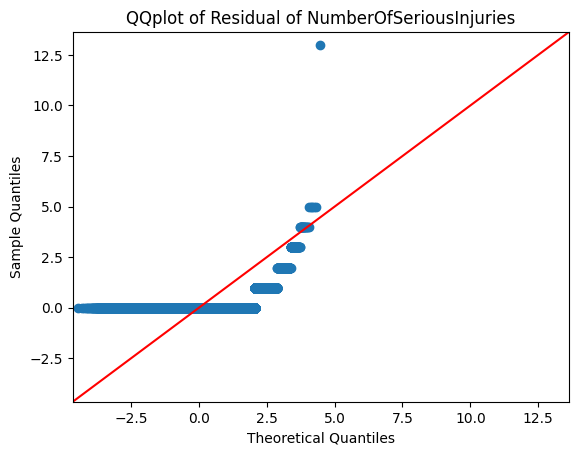

In [35]:
sm.qqplot(residuals, line='45')
plt.title("QQplot of Residual of NumberOfSeriousInjuries")
plt.show()

# Thruway Analysis (Not used)

In [36]:
# summary = clean.groupby("OWNING_JURISDICTION")["NumberOfSeriousInjuries"].agg(
#     count = "count",
#     mean = "mean",
#     median = "median",
#     std= "std"
# )
# print(summary.sort_values("mean", ascending = False))

KeyError: 'Column not found: NumberOfSeriousInjuries'

In [ ]:
# plt.figure(figsize= (10,6))
# sns.boxplot(data = clean, x="OWNING_JURISDICTION", y="NumberOfSeriousInjuries")
# plt.xticks(rotation=45)
# plt.title("Serious Injury Boxplot by Owning Jurisdiction")
# plt.show()

In [ ]:
# print(clean2["OWNING_JURISDICTION"].value_counts())

In [ ]:
# One explanation is limited statistical power. The Thruway group contains fewer observations than several other jurisdiction categories, 
# making it harder to detect pairwise differences after multiple-comparison adjustment.

In [ ]:
# clean["is_thruway"] = (clean["OWNING_JURISDICTION"] == "Thruway").astype(int)

# x1 = clean.loc[clean["is_thruway"] == 1, "NumberOfSeriousInjuries"].dropna()
# x0 = clean.loc[clean["is_thruway"] == 0, "NumberOfSeriousInjuries"].dropna()

# from scipy.stats import mannwhitneyu
# stat, p = mannwhitneyu(x1, x0, alternative="two-sided")

# print("Thruway mean:", x1.mean(), "median:", x1.median(), "n:", len(x1))
# print("Non-Thruway mean:", x0.mean(), "median:", x0.median(), "n:", len(x0))
# print("p-value:", p)

In [ ]:
# A focused comparison between Thruway and non-Thruway crashes was conducted using the Mann-Whitney U test on NumberOfSeriousInjuries. The result was
# not statistically significant (p = 0.1605), suggesting that the distribution of serious injury counts does not differ strongly between the two groups.